In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys

In [6]:
%config InlineBackend.figure_format ='retina'
sns.set(style="whitegrid")

In [7]:
project_root = os.path.abspath("..")
sys.path.append(project_root)  # Add to sys.path
print("Project root added to sys.path:", project_root)

Project root added to sys.path: /Users/anacontreras/Documents/Projects/QuantFinance


In [8]:
from FX.option_replication import RiskReversalMomentum

In [ ]:
rrm = RiskReversalMomentum('EURUSD', 42, 252, '12-12-2005', '03-24-2020')

In [11]:
data = pd.read_csv("mktdata_EURUSD.csv")

In [12]:
data.head()

,date,Spot,ImpVol,RiskRev,Bfly,IR_X,IR_Y
0,12/12/2005,1.1974,0.09025,0.100,0.15,2.5437,4.36750
1,13/12/2005,1.1935,0.08900,0.100,0.15,2.5466,4.36938
2,14/12/2005,1.2019,0.09025,0.200,0.15,2.5516,4.37000
3,15/12/2005,1.1957,0.08775,0.150,0.15,2.5554,4.37000
4,16/12/2005,1.2007,0.08525,0.125,0.15,2.5585,4.37000


In [13]:
def log_return(spot):

    return np.log(spot).diff()

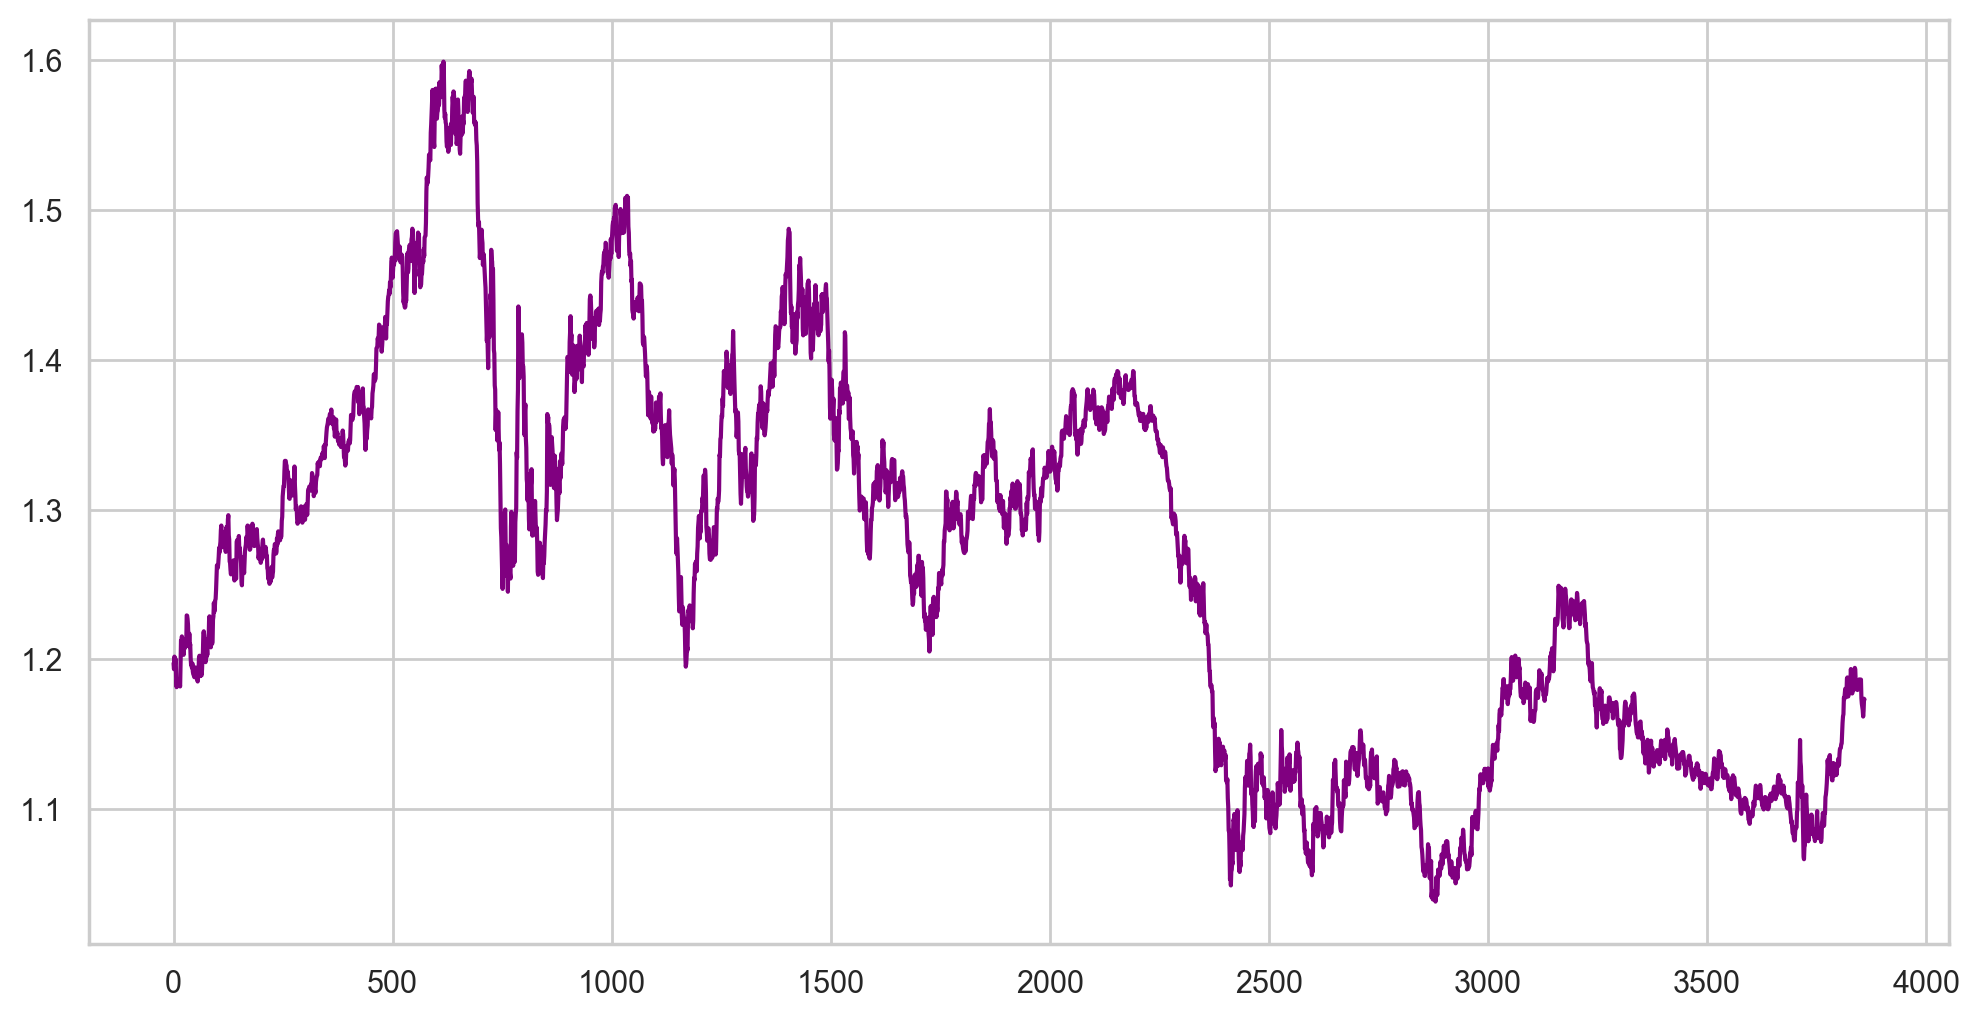

In [20]:
plt.figure(figsize=(12, 6))
data["Spot"].plot(color="purple")
plt.show()

In [31]:
def realised_vol(spot_return, decay=0.97):
    return_ewma = spot_return.ewm(com=decay / (1.0 - decay), adjust=False).mean()
    adjReturn = spot_return - return_ewma
    adjReturnSqr = 252 * adjReturn * adjReturn
    variance_ewma = adjReturnSqr.ewm(com=decay / (1.0 - decay), adjust=False).mean()
    return np.sqrt(variance_ewma)


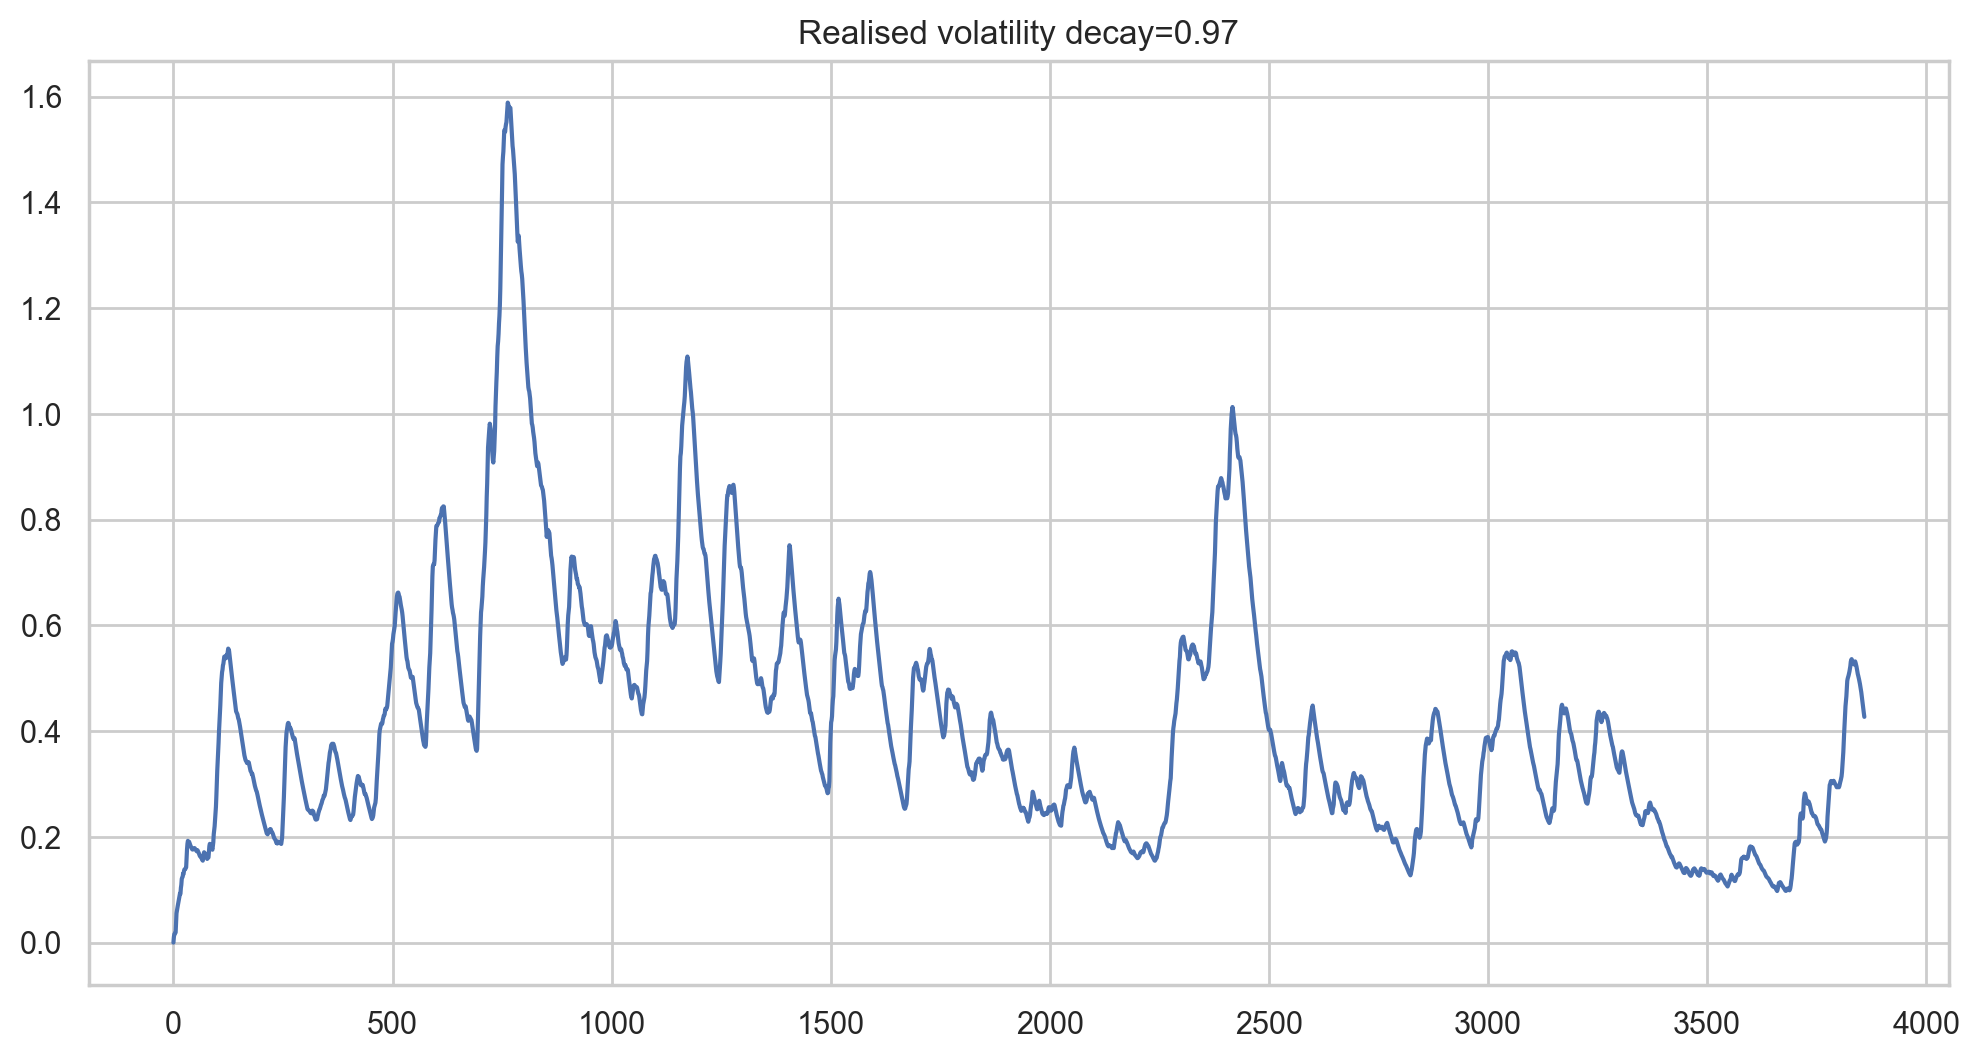

In [36]:
plt.figure(figsize=(12, 6))
realised_vol(data["Spot"], decay=0.97).plot()
plt.title('Realised volatility decay=0.97')
plt.show()

In [42]:
def tstat_deltaRR(RR, decay=0.97):
    deltaRR = RR.diff()
    deltaRRsqr = deltaRR * deltaRR
    beta = deltaRR.ewm(com=decay / (1.0 - decay), adjust=False).mean()
    gamma = deltaRRsqr.ewm(com=decay / (1.0 - decay), adjust=False).mean()
    window_size = round(1.5 * (1 + decay) / (1 - decay))
    stdErr = np.sqrt((gamma - beta * beta) / (window_size - 1))
    result = beta / stdErr
    return result

In [43]:
data["rr_mom"] = tstat_deltaRR(data["RiskRev"])

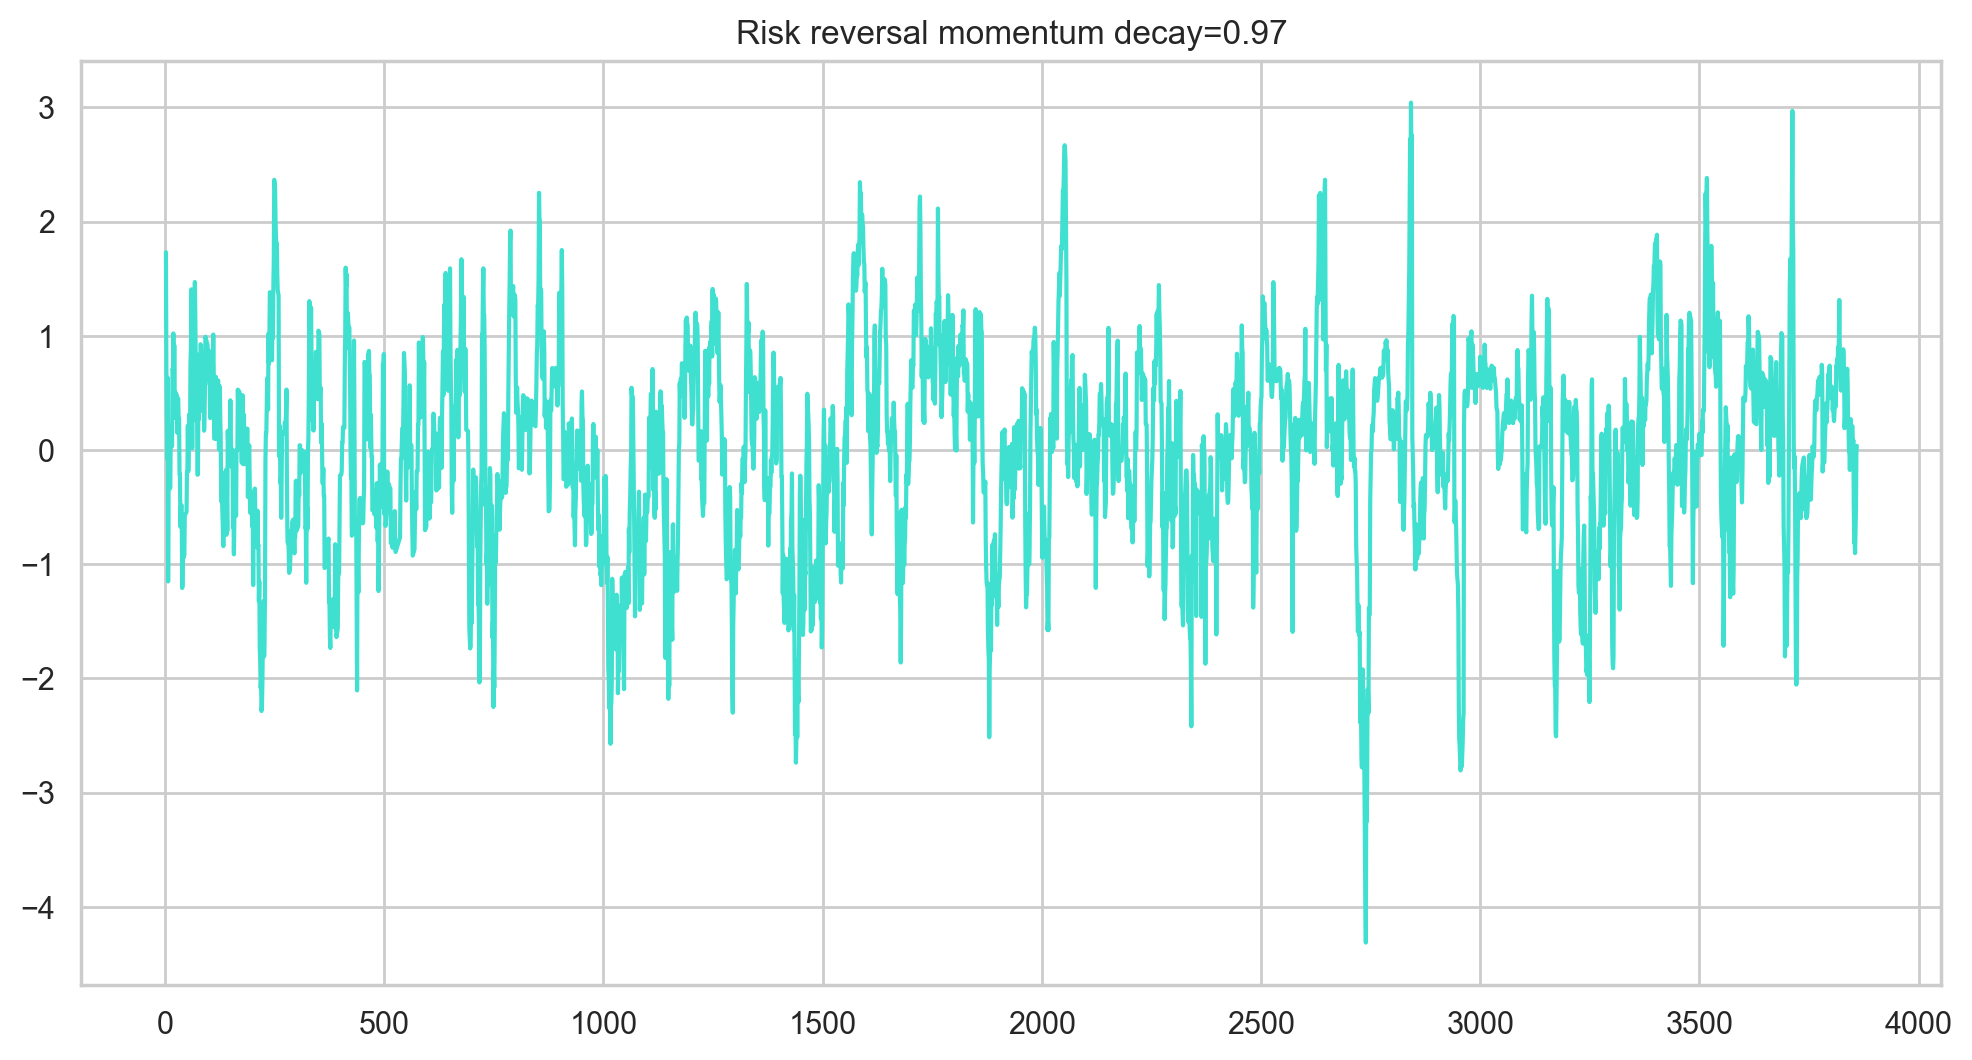

In [52]:
plt.figure(figsize=(12, 6))
data["rr_mom"].plot(color="turquoise")
plt.title('Risk reversal momentum decay=0.97')
plt.show()

In [53]:
def smoothing_tstats(e):
    smt_param = 1
    if np.abs(e) > smt_param:
        return np.sign(e)
    else:
        return np.sin(e * np.pi / (2 * smt_param))

In [56]:
rr_mom = data["rr_mom"].apply(smoothing_tstats, args=())

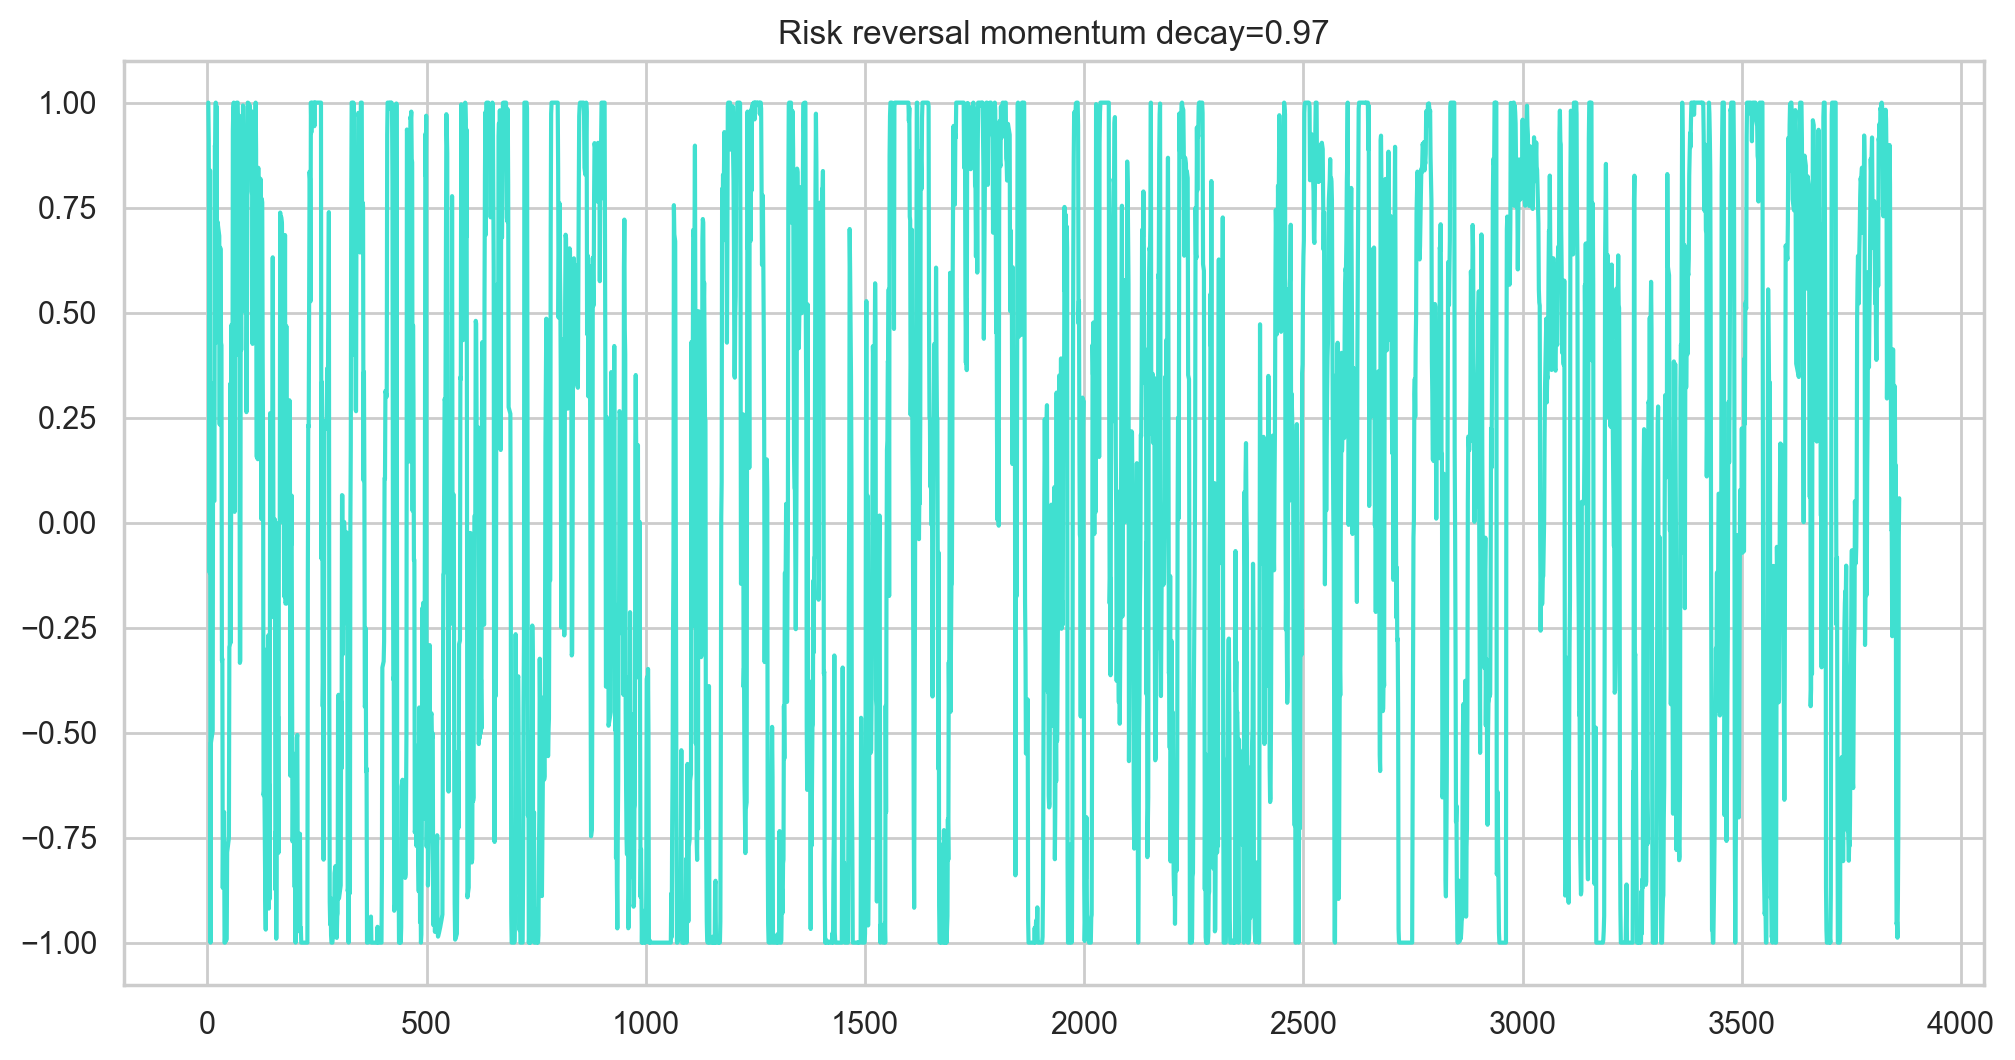

In [57]:
plt.figure(figsize=(12, 6))
rr_mom.plot(color="turquoise")
plt.title('Risk reversal momentum decay=0.97')
plt.show()

In [58]:
data['signal'] = rr_mom

In [60]:
data['ir_diff'] = data['IR_Y'] - data['IR_X']

In [62]:
pnl = log_return(data['Spot']) * data['signal'].shift(1)

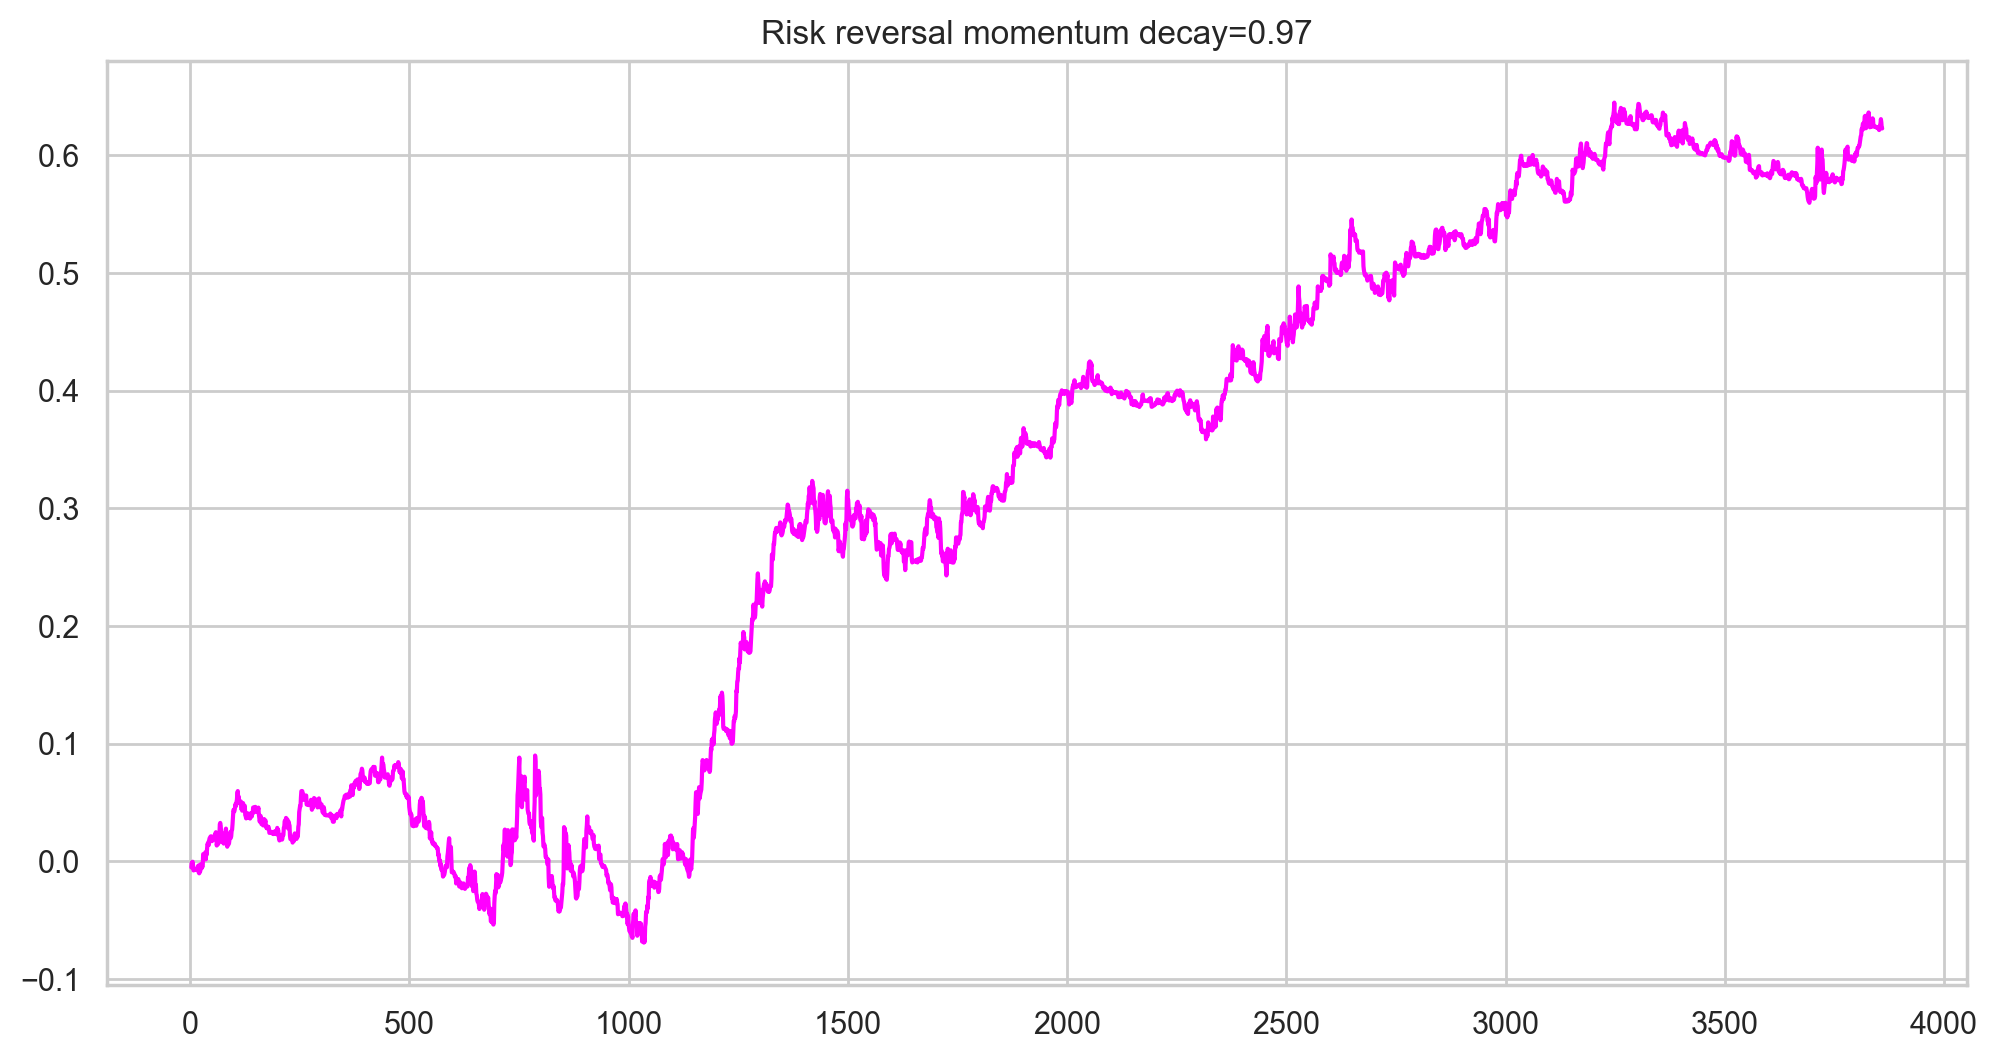

In [64]:
plt.figure(figsize=(12, 6))
pnl.cumsum().plot(color="magenta")
plt.title('Risk reversal momentum decay=0.97')
plt.show()

In [ ]:
from 